In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("data/train.csv")

# Display first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Dataset Overview

The House Prices dataset contains information about residential properties
and their characteristics. The objective of this project is to build a
Linear Regression model that predicts the sale price of a house (`SalePrice`)
using relevant numerical and categorical features.

In [3]:
# Check dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1460
Number of columns: 81


In [4]:
# Display column names and data types

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
# Descriptive statistics

df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
# Check missing values

missing_values = df.isnull().sum()

# Display only columns having missing values
missing_values[missing_values > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [7]:
# Missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_df = missing_df[missing_df["Missing Values"] > 0] \
    .sort_values("Percentage", ascending=False)

missing_df

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [8]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
# Descriptive statistics of SalePrice

df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

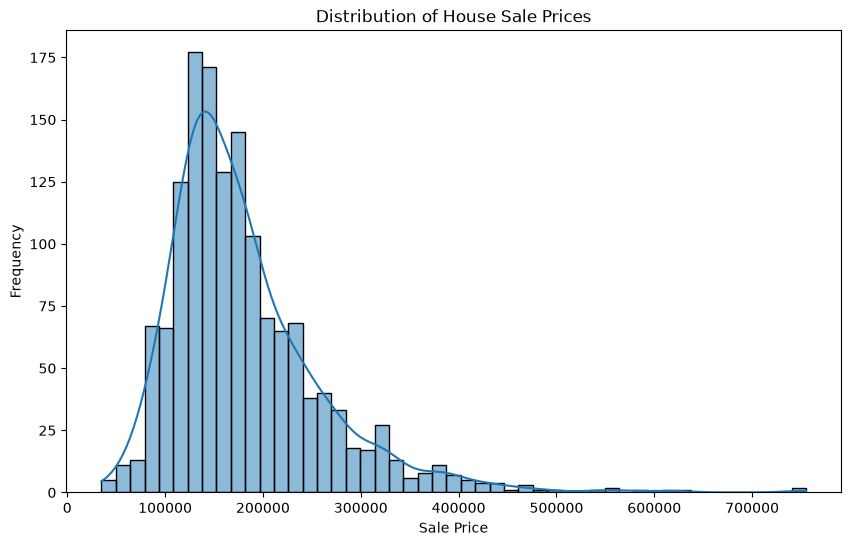

In [10]:
# Distribution of house prices

plt.figure(figsize=(10, 6))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

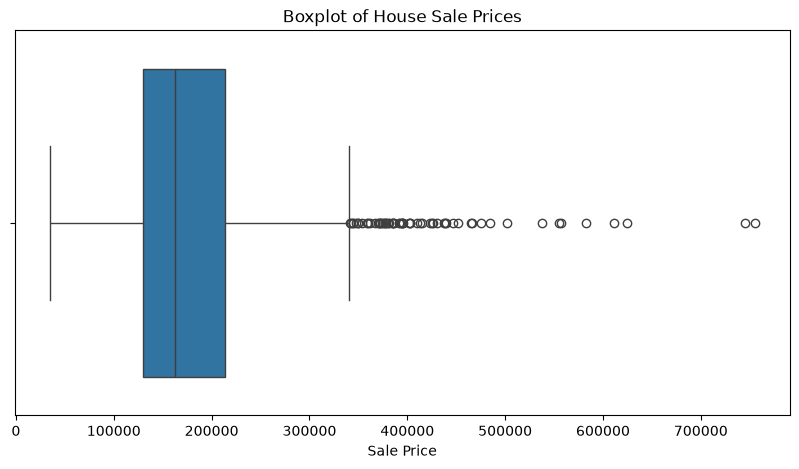

In [11]:
# Boxplot of SalePrice

plt.figure(figsize=(10, 5))

sns.boxplot(x=df["SalePrice"])

plt.title("Boxplot of House Sale Prices")
plt.xlabel("Sale Price")

plt.show()

## 5. Feature Selection Discussion

The target variable for this project is `SalePrice`, which represents the
final selling price of each house.

Several features are likely to be strong predictors of house prices:

- `OverallQual` – Overall material and finish quality of the house.
- `GrLivArea` – Above-ground living area in square feet.
- `GarageCars` – Number of cars that can be accommodated in the garage.
- `TotalBsmtSF` – Total basement area.
- `1stFlrSF` – First-floor area.
- `YearBuilt` – Year in which the house was originally constructed.
- `FullBath` – Number of full bathrooms.
- `BedroomAbvGr` – Number of bedrooms above ground.
- `GarageArea` – Size of the garage.
- `TotRmsAbvGrd` – Total number of rooms above ground.

These features are selected because house size, quality, age, number of
rooms, bathrooms, and garage capacity are expected to have a meaningful
relationship with the selling price.

Categorical variables such as `Neighborhood`, `HouseStyle`, and
`Foundation` may also contain useful information and will be encoded using
One-Hot Encoding./'

In [12]:
# Correlation with SalePrice

correlation = df.select_dtypes(include=np.number).corr()["SalePrice"]

correlation = correlation.sort_values(ascending=False)

correlation.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

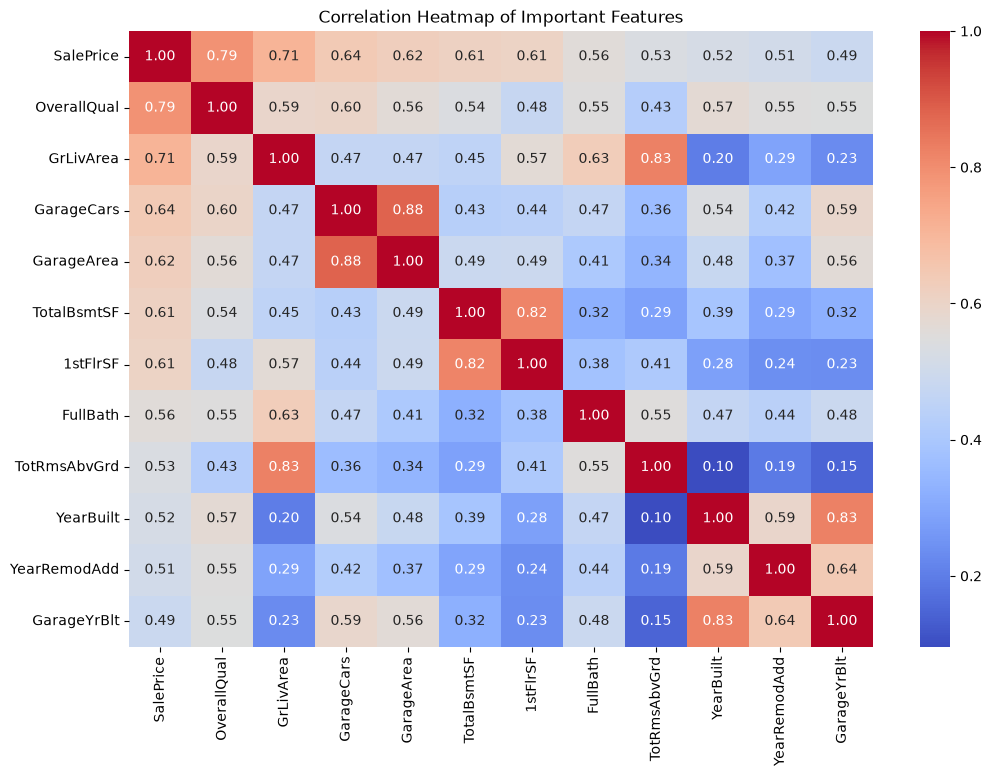

In [13]:
# Select important numerical features for correlation heatmap

top_features = correlation.head(12).index

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Important Features")

plt.show()

In [14]:
# Separate features and target

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 80)
Target shape: (1460,)


In [15]:
# Remove ID column

X = X.drop("Id", axis=1)

In [16]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 36
Number of categorical features: 43


C:\Users\kishw\AppData\Local\Temp\ipykernel_15888\4061455932.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1168
Testing samples: 292


In [19]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression pipeline
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [20]:
# Predict house prices

y_pred = linear_model.predict(X_test)

print("First 10 actual prices:")
print(y_test.iloc[:10].values)

print("\nFirst 10 predicted prices:")
print(y_pred[:10])

First 10 actual prices:
[154500 325000 115000 159000 315500  75500 311500 146000  84500 135500]

First 10 predicted prices:
[151971.20051183 356441.14089892  95590.88330007 177919.63763369
 342171.21147719  59615.31585659 253448.9505881  153388.03759418
  53796.95852136 149553.68215884]


In [21]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R²
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("================")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation
MSE  : 979,376,460.09
RMSE : 31,294.99
R²   : 0.8723


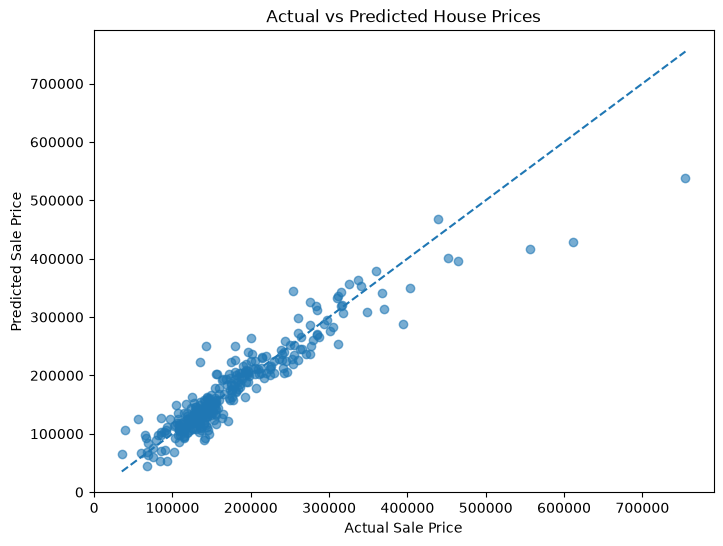

In [22]:
# Actual vs Predicted Prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [24]:
# Calculate residuals

residuals = y_test - y_pred


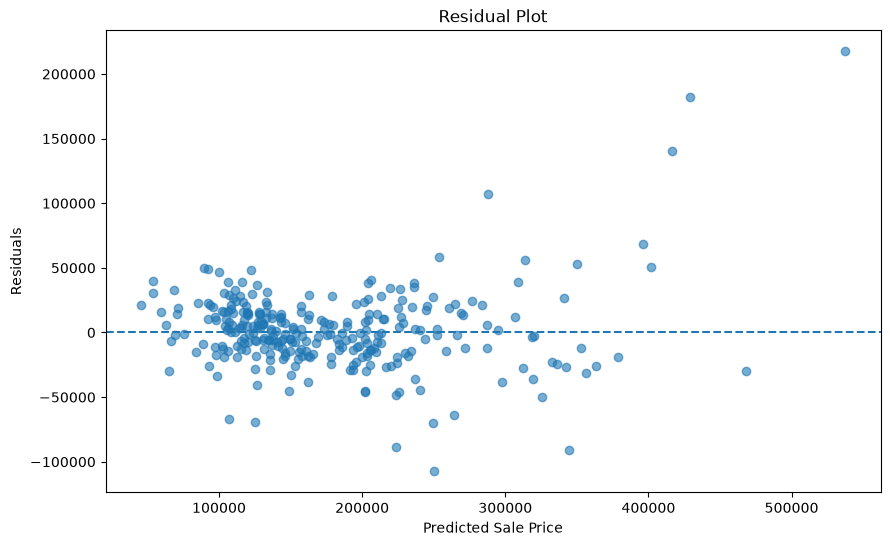

In [25]:
# Residual plot

plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [26]:
# Get feature names after preprocessing

feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

# Get model coefficients
coefficients = linear_model.named_steps["regressor"].coef_

# Create coefficient DataFrame
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by coefficient
coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_df.head(15)

,Feature,Coefficient
78,cat__Neighborhood_NoRidge,41901.268218
85,cat__Neighborhood_StoneBr,39134.933544
259,cat__PoolQC_Ex,28020.792433
79,cat__Neighborhood_NridgHt,24777.963772
134,cat__Exterior1st_BrkFace,23198.043843
153,cat__Exterior2nd_ImStucc,21429.506595
180,cat__BsmtQual_Ex,20061.527068
221,cat__KitchenQual_Ex,19445.880060
50,cat__LandContour_HLS,18920.803465
69,cat__Neighborhood_Crawfor,16885.159464


In [27]:
# Top 10 features with positive coefficients

top_positive = coefficient_df.head(10)

top_positive

,Feature,Coefficient
78,cat__Neighborhood_NoRidge,41901.268218
85,cat__Neighborhood_StoneBr,39134.933544
259,cat__PoolQC_Ex,28020.792433
79,cat__Neighborhood_NridgHt,24777.963772
134,cat__Exterior1st_BrkFace,23198.043843
153,cat__Exterior2nd_ImStucc,21429.506595
180,cat__BsmtQual_Ex,20061.527068
221,cat__KitchenQual_Ex,19445.880060
50,cat__LandContour_HLS,18920.803465
69,cat__Neighborhood_Crawfor,16885.159464


In [28]:
# Top 10 features with negative coefficients

top_negative = coefficient_df.tail(10).sort_values(
    by="Coefficient"
)

top_negative

,Feature,Coefficient
124,cat__RoofMatl_ClyTile,-29057.711990
261,cat__PoolQC_Gd,-24972.333443
101,cat__Condition2_PosN,-24387.894785
74,cat__Neighborhood_Mitchel,-21248.184226
49,cat__LandContour_Bnk,-20468.188112
70,cat__Neighborhood_Edwards,-17223.304884
47,cat__LotShape_IR3,-15412.090547
71,cat__Neighborhood_Gilbert,-14890.232469
77,cat__Neighborhood_NWAmes,-14294.379434
75,cat__Neighborhood_NAmes,-13055.799494


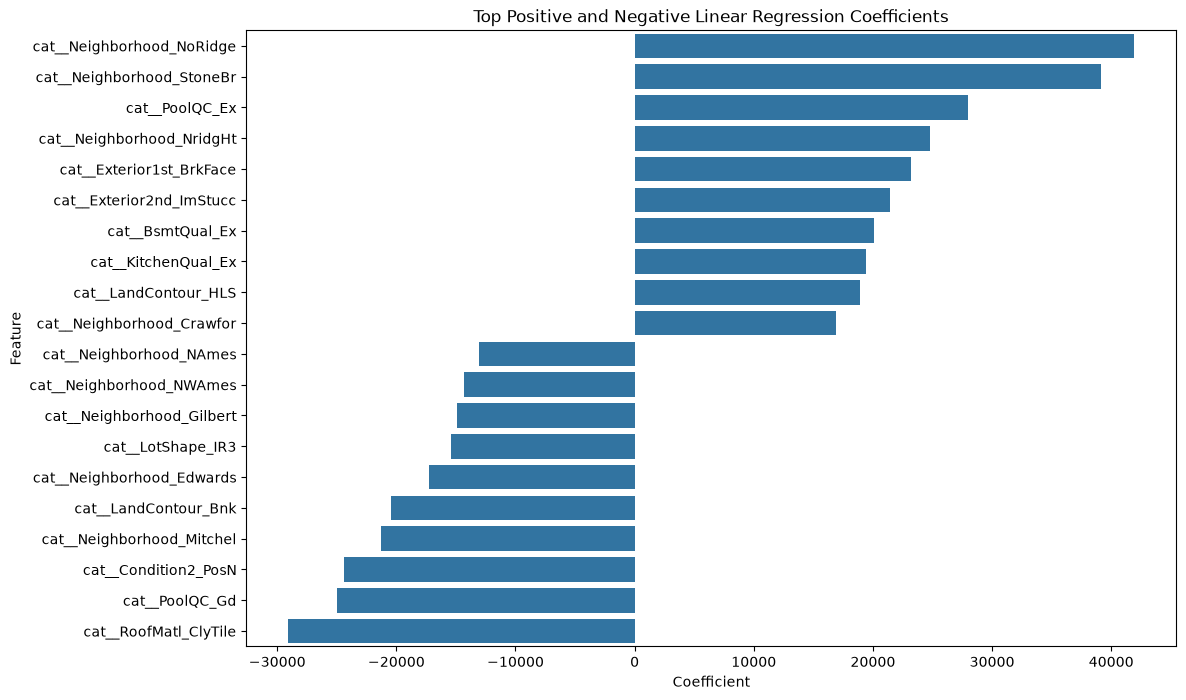

In [29]:
# Plot top positive and negative coefficients

top_positive_negative = pd.concat([
    coefficient_df.head(10),
    coefficient_df.tail(10)
])

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_positive_negative,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Positive and Negative Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

## Coefficient Analysis

The coefficients represent the estimated change in house price associated
with a feature while keeping the other features constant.

A positive coefficient indicates that an increase or presence of the feature
is associated with an increase in the predicted house price.

A negative coefficient indicates an inverse relationship with the predicted
price.

For categorical variables, the coefficients represent the effect of the
corresponding one-hot encoded category relative to the reference categories.

The magnitude of coefficients should be interpreted carefully because
numerical features are measured on different scales.

In [30]:
from sklearn.linear_model import Ridge

In [31]:
# Ridge Regression pipeline

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=10.0))
])

# Train Ridge model
ridge_model.fit(X_train, y_train)

# Predictions
ridge_pred = ridge_model.predict(X_test)

# Evaluation
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("================")
print(f"MSE  : {ridge_mse:,.2f}")
print(f"RMSE : {ridge_rmse:,.2f}")
print(f"R²   : {ridge_r2:.4f}")

Ridge Regression
MSE  : 1,194,764,740.27
RMSE : 34,565.37
R²   : 0.8442


In [32]:
from sklearn.linear_model import Lasso

In [33]:
# Lasso Regression pipeline

lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=100.0, max_iter=10000))
])

# Train Lasso model
lasso_model.fit(X_train, y_train)

# Predictions
lasso_pred = lasso_model.predict(X_test)

# Evaluation
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression")
print("================")
print(f"MSE  : {lasso_mse:,.2f}")
print(f"RMSE : {lasso_rmse:,.2f}")
print(f"R²   : {lasso_r2:.4f}")

Lasso Regression
MSE  : 801,128,033.58
RMSE : 28,304.21
R²   : 0.8956


In [34]:
# Model comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MSE": [
        mse,
        ridge_mse,
        lasso_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        lasso_rmse
    ],
    "R2 Score": [
        r2,
        ridge_r2,
        lasso_r2
    ]
})

model_comparison

,Model,MSE,RMSE,R2 Score
0,Linear Regression,9.793765e+08,31294.990974,0.872316
1,Ridge Regression,1.194765e+09,34565.369089,0.844235
2,Lasso Regression,8.011280e+08,28304.205228,0.895555


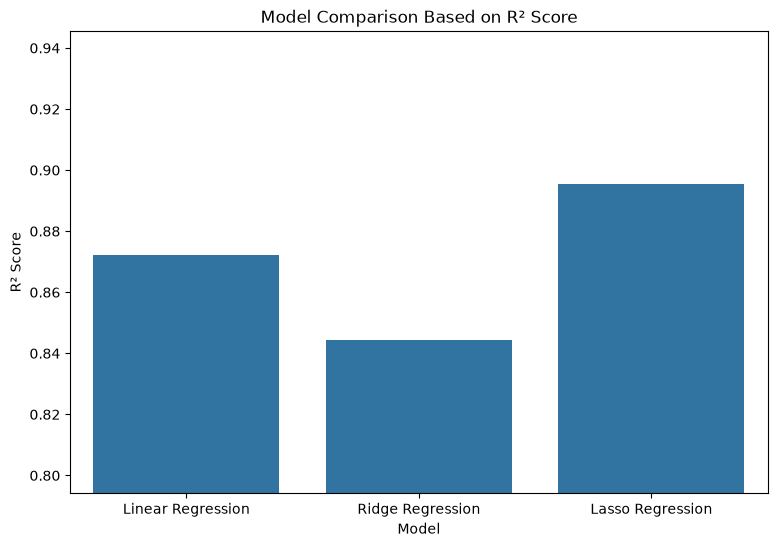

In [35]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison Based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.ylim(
    min(model_comparison["R2 Score"]) - 0.05,
    min(1, max(model_comparison["R2 Score"]) + 0.05)
)

plt.show()

In [36]:
# Identify the best model based on R²

best_model = model_comparison.loc[
    model_comparison["R2 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model       Lasso Regression
MSE         801128033.584434
RMSE            28304.205228
R2 Score            0.895555
Name: 2, dtype: object


## Conclusion

In this project, a Linear Regression model was developed to predict house
sale prices using property-related features from the Ames Housing dataset.

The dataset was explored through descriptive statistics, missing-value
analysis, target-variable distribution, and correlation analysis.

Numerical missing values were handled using median imputation, while
categorical missing values were handled using the most frequent category.
Categorical variables were converted into numerical representations using
One-Hot Encoding.

The dataset was divided into training and testing sets using an 80/20 split.
A Linear Regression model was then trained and evaluated using Mean Squared
Error (MSE), Root Mean Squared Error (RMSE), and R² score.

Actual-versus-predicted and residual plots were used to visually evaluate
model performance. Coefficient analysis was also performed to identify
features having the strongest positive and negative effects on predicted
house prices.

Finally, Linear Regression was compared with Ridge and Lasso Regression.
Regularization can help reduce the impact of multicollinearity and prevent
overly complex models. The model with the highest R² score and lowest
prediction error can be selected as the best-performing model for this
dataset.

Overall, the project demonstrates a complete machine-learning workflow from
data exploration and preprocessing to model training, evaluation,
interpretation, and comparison.